In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
import neurokit2 as nk
import wfdb

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("tensorflow:", tf.__version__)
print("neurokit2:", nk.__version__)
print("All libraries loaded successfully! ✅")

numpy: 1.26.4
pandas: 3.0.1
tensorflow: 2.21.0
neurokit2: 0.2.12
All libraries loaded successfully! ✅


In [4]:
wfdb.dl_database('mitdb', dl_dir='../data/mitdb')
print("MIT-BIH database downloaded! ✅")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [5]:
pip install biosppy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [biosppy]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Sampling rate: 360 Hz
Signal length: 10000 samples
Duration: 27.8 seconds


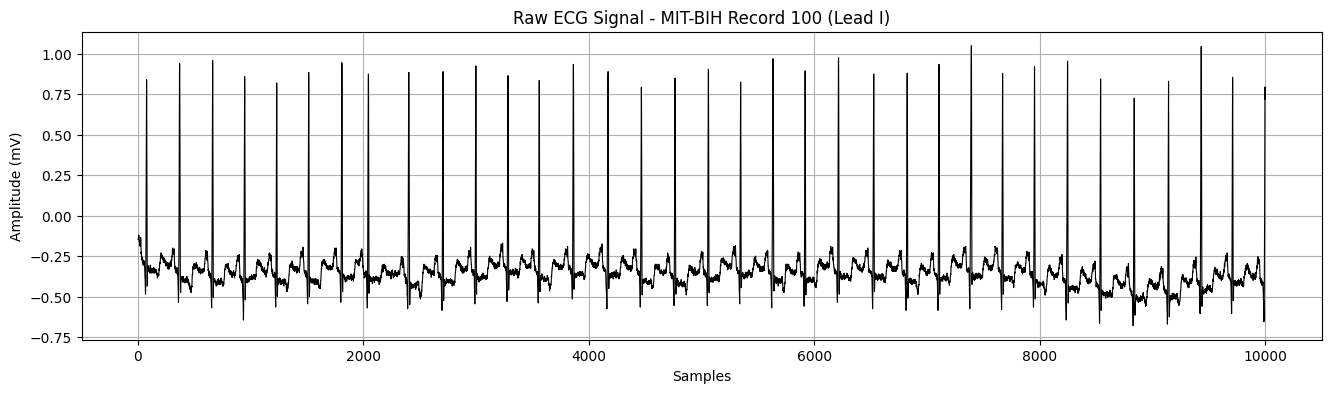

In [1]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from biosppy.signals import ecg

# Load ECG record 100 from MIT-BIH (10 seconds of data)
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=10000)
ecg_signal = record.p_signal[:, 0]  # Lead I
fs = record.fs

print(f"Sampling rate: {fs} Hz")
print(f"Signal length: {len(ecg_signal)} samples")
print(f"Duration: {len(ecg_signal)/fs:.1f} seconds")

# Plot the raw ECG
plt.figure(figsize=(16, 4))
plt.plot(ecg_signal, color='black', linewidth=0.8)
plt.title("Raw ECG Signal - MIT-BIH Record 100 (Lead I)")
plt.xlabel("Samples")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'peakutils'])


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


CompletedProcess(args=['pip', 'install', 'peakutils'], returncode=0)

Number of beats detected: 34
Average heart rate: 74.3 bpm


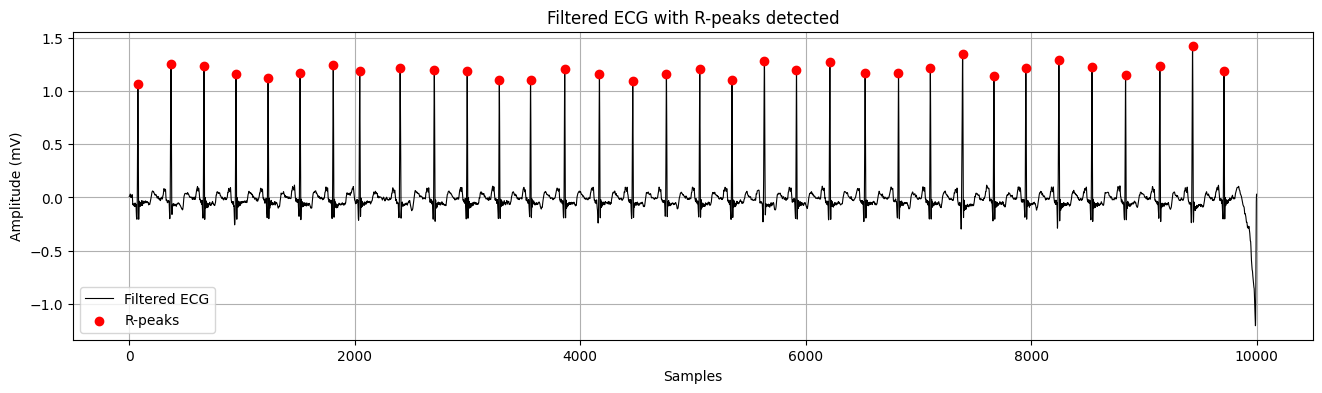

In [3]:
# Process ECG with biosppy - detects R-peaks automatically
out = ecg.ecg(signal=ecg_signal, sampling_rate=fs, show=False)

rpeaks = out['rpeaks']
templates = out['templates']
heart_rate = out['heart_rate']
filtered = out['filtered']

print(f"Number of beats detected: {len(rpeaks)}")
print(f"Average heart rate: {np.mean(heart_rate):.1f} bpm")

# Plot filtered ECG with R-peaks marked in red
plt.figure(figsize=(16, 4))
plt.plot(filtered, label='Filtered ECG', color='black', linewidth=0.8)
plt.scatter(rpeaks, filtered[rpeaks], color='red', label='R-peaks', zorder=5)
plt.title("Filtered ECG with R-peaks detected")
plt.xlabel("Samples")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
import wfdb
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import random

# Download MIT-BIH if not already done
wfdb.dl_database('mitdb', './mitdb')

def load_beats(record_id):
    try:
        record = wfdb.rdrecord(f'mitdb/{record_id}')
        annotation = wfdb.rdann(f'mitdb/{record_id}', 'atr')
    except:
        return [], []

    signal = record.p_signal[:, 0]
    beat_samples = annotation.sample
    labels = annotation.symbol

    beats = []
    classes = []

    for i, sym in enumerate(labels):
        if sym not in ['N', 'V']:
            continue
        r = beat_samples[i]
        if r - 50 < 0 or r + 50 > len(signal):
            continue
        beat = signal[r - 50:r + 50]
        beats.append(beat)
        classes.append(sym)

    return beats, classes

# Load from records 100-130
N_beats, V_beats = [], []
for pid in range(100, 131):
    beats, labels = load_beats(str(pid))
    for b, l in zip(beats, labels):
        if l == 'N':
            N_beats.append(b)
        elif l == 'V':
            V_beats.append(b)

print(f"Total Normal beats: {len(N_beats)}")
print(f"Total PVC beats: {len(V_beats)}")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [5]:
# Balance the classes
min_len = min(len(N_beats), len(V_beats))
N_balanced = random.sample(N_beats, min_len)
V_balanced = random.sample(V_beats, min_len)

# Combine and create labels
X = np.array(N_balanced + V_balanced)
y = np.array([0] * min_len + [1] * min_len)  # 0=Normal, 1=PVC

# Shuffle
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Train model
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Evaluat

LogisticRegression(max_iter=1000)

Classification Report:

              precision    recall  f1-score   support

      Normal       0.90      0.94      0.92       270
         PVC       0.94      0.89      0.91       269

    accuracy                           0.92       539
   macro avg       0.92      0.92      0.92       539
weighted avg       0.92      0.92      0.92       539

Confusion Matrix:
[[254  16]
 [ 29 240]]


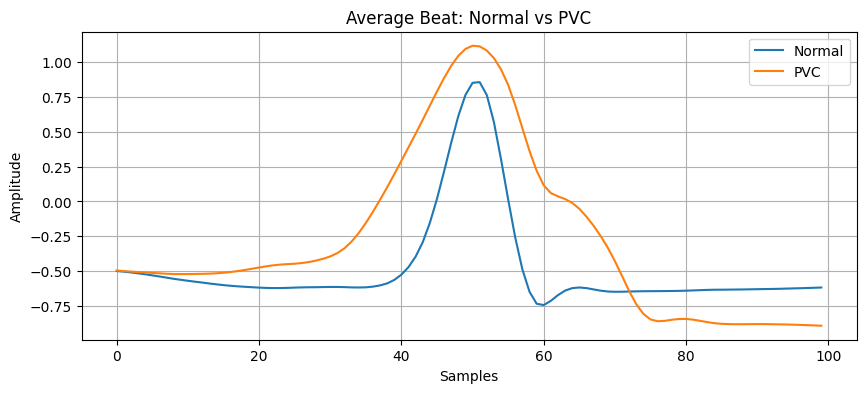

In [6]:
# Evaluate the model
y_pred = clf.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'PVC']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Plot average Normal vs PVC beat
plt.figure(figsize=(10, 4))
for label in [0, 1]:
    label_name = "Normal" if label == 0 else "PVC"
    avg_beat = np.mean(X[y == label], axis=0)
    plt.plot(avg_beat, label=label_name)
plt.title("Average Beat: Normal vs PVC")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
import joblib
import os

# Save the trained model
os.makedirs('../models', exist_ok=True)
joblib.dump(clf, '../models/ecg_classifier_v1.pkl')
print("Model saved! ✅")

# Save some test data for later use
np.save('../models/X_test.npy', X_test)
np.save('../models/y_test.npy', y_test)
print("Test data saved! ✅")

Model saved! ✅
Test data saved! ✅
